In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

In [3]:
#at home

mu = 10           
sigma = 2         
n = 30    
N_trials = 1000

means = []
stds = []

for _ in range(N_trials):
    sample = np.random.normal(mu, sigma, n)
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    means.append(x_bar)
    stds.append(s)

means = np.array(means)
stds = np.array(stds)

mean_of_means = np.mean(means)
std_of_means = np.std(means, ddof=1)  

mean_of_stds = np.mean(stds)
std_of_stds = np.std(stds, ddof=1)  

# Theoretical
error_mean_theory = sigma / np.sqrt(n)

error_s_teorico_alt = (1 / np.sqrt(2)) * np.sqrt(n / (n - 1)) * error_mean_theory

#lets see if they agre
print(f"Results for {N_trials} realizations with samples size of n = {n} \n")
print(f"Median of x̄: {mean_of_means:.4f}")
print(f"Error of x̄: {std_of_means:.4f}")
print(f"Theoretical Error of x̄:  {error_mean_theory:.4f}\n")

print(f"Mean of s: {mean_of_stds:.4f}")
print(f"Error of s: {std_of_stds:.4f}")
print(f"Theoretical Error of s:: {error_s_teorico_alt:.4f}")


 Results for 1000 realizations with samples size of n = 30 

Median of x̄: 9.9961
Error of x̄: 0.3672
Theoretical Error of x̄:  0.3651

Mean of s: 1.9656
Error of s: 0.2612
Theoretical Error of s:: 0.2626


In [4]:
#about the horses

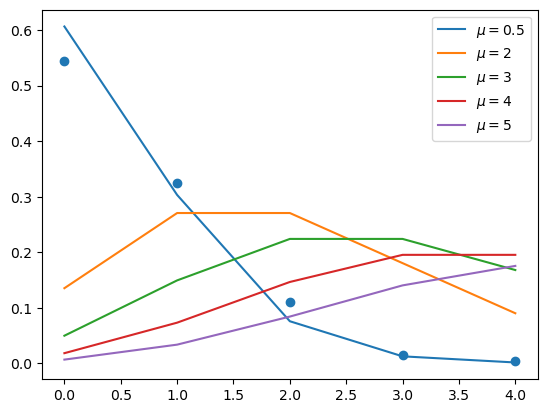

In [5]:
events=[0,1,2,3,4]
data=np.array([109,65,22,3,1])
data=data/sum(data)

plt.scatter(events, data) #i think can be a poissionan dist actually, since is number of events changing with corpy

for u in [0.5,2,3,4,5]:
    Po=scipy.stats.poisson(u).pmf(events)
    plt.plot(events,Po,label='$\mu='+str(u)+"$")
plt.legend();


In [6]:
##Theoretically if you want a good poisson dist, so the mean should be equal to mu, so, what if the mean is mu??

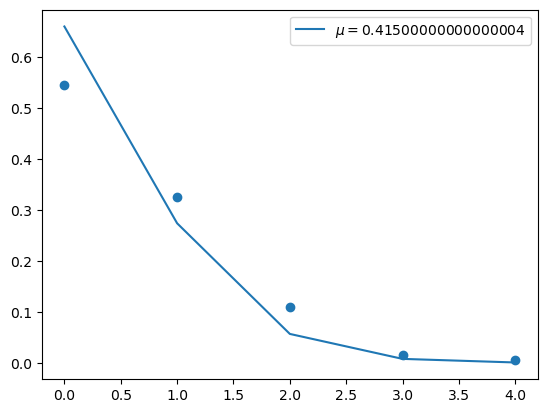

In [7]:
mu_real=np.average(data, weights=data)
plt.scatter(events, data)
Po=scipy.stats.poisson(mu_real).pmf(events)
plt.plot(events,Po,label='$\mu='+str(mu_real)+"$")
plt.legend()

#here i just plot the possionan dist with a median equal ot the mena of the data, seems to be a possionan.

In [8]:
##Not the ebst actually. but lets do the nasty integral

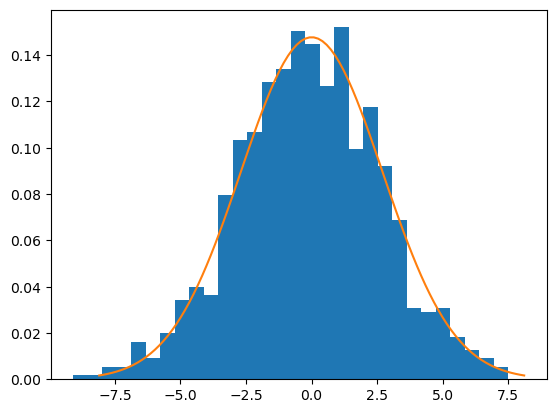

In [9]:
sigma=2.7
N=1000

gauss = scipy.stats.norm(loc=0,scale=sigma)
x=gauss.rvs(N)

plt.hist(x, bins=30, density=True);
plt.plot(np.linspace(-3*sigma,3*sigma,100), gauss.pdf(np.linspace(-3*sigma,3*sigma,100)))

In [10]:
sampling=np.abs(gauss.rvs(N)) #just sampling from 0 to in inf
I=np.mean(sampling**3) * (2/np.pi)**(-1/2) * sigma
I_real= 2*sigma**4
print(f"The integral estimated using the Monte Carlo method is: {I:.5f}")
print(f"The analytical value of the integral is: {I_real:.5f}")
print(f"The relative error is: {100 * np.abs((I_real - I) / I_real):.3f}%")

The integral estimated using the Monte Carlo method is: 107.75786
The analytical value of the integral is: 106.28820
The relative error is: 1.383%


[]

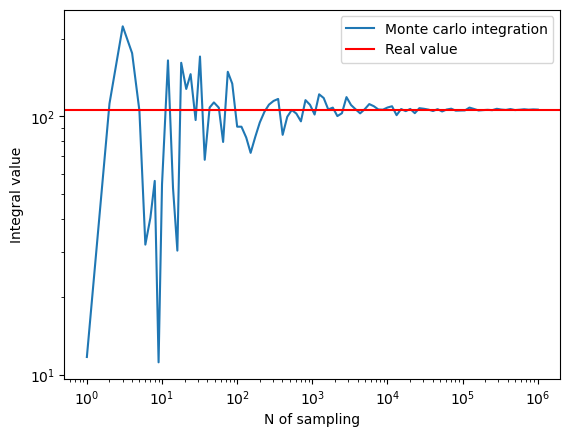

In [11]:
def funcion(sigma, N):
    gauss = scipy.stats.norm(loc=0,scale=sigma)
    sampling=np.abs(gauss.rvs(N))
    return np.mean(sampling**3) * (2/np.pi)**(-1/2) * sigma

def knownresult(sigma):
    return 2*sigma**4

N=np.unique(np.logspace(0,6,100,dtype=int))
attemps=[funcion(sigma, Nval) for Nval in N]
plt.plot(N,attemps, label='Monte carlo integration')
plt.axhline(knownresult(sigma),color="r", label='Real value')
plt.xlabel('N of sampling')
plt.ylabel('Integral value')
plt.legend()
plt.loglog()

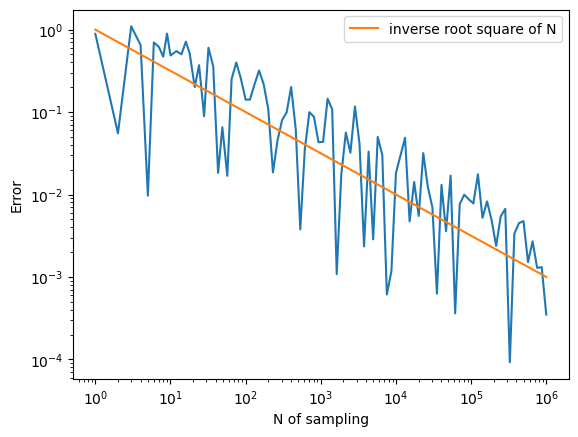

In [12]:
error= np.abs((np.array(attemps)-knownresult(sigma))/knownresult(sigma))

plt.plot(N, error)
plt.plot(N, N**-0.5, label='inverse root square of N')
plt.loglog()
plt.xlabel('N of sampling')
plt.ylabel('Error')
plt.legend();

In [13]:
#lets do i N tines
N= 1000 #samplings
N_2 = 10000 #times
integral=[]
for i in range(N_2):
    x=funcion(sigma,N)
    integral.append(x)


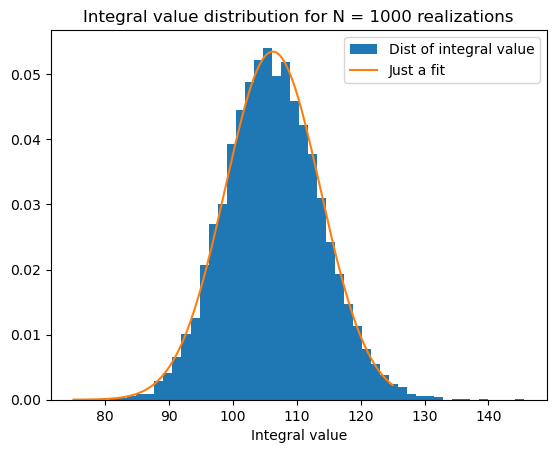

In [14]:
plt.hist(integral, density=True, bins=50, label='Dist of integral value'); #seems to be a gaussian, lets just fir with a gaussian.
mean = np.average(integral)
sigma = np.std(integral)
gauss2 = scipy.stats.norm(loc=mean,scale=sigma)
x = np.linspace(75,125,1000)
plt.plot(x,gauss2.pdf(x), label='Just a fit')
plt.xlabel('Integral value')
plt.title(f'Integral value distribution for N = {N} realizations')
plt.legend();

In [ ]:
#just probing the LCT 